In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[15000, 4000],
    lows=[1000, 500],
    reset_previous=True,
)
# Remake HVGs after this tutorial's cell filter so lineage does not pull in a
# feature selection that was computed under an earlier cell mask on the store.
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

Computing RNA feature statistics: 6 / 6 complete

In [2]:
normalized = ds.run_normalization(
    feat_key='hvgs',
    update_state=False,
)
pca = ds.run_pca(normalized, dims=15, update_state=False)
ann = ds.build_ann_index(pca, update_state=False)
neighbors_k11 = ds.query_neighbors(ann, k=11, update_state=False)
graph_k11 = ds.build_connectivity_map(neighbors_k11, update_state=False)

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [3]:
neighbors_k15 = ds.query_neighbors(ann, k=15, update_state=False)
graph_k15 = ds.build_connectivity_map(neighbors_k15, update_state=False)

print('normalization reused:', ds.run_normalization(feat_key='hvgs', update_state=False) == normalized)
print('PCA reused:', ds.run_pca(normalized, dims=15, update_state=False) == pca)
print('ANN index reused:', ds.build_ann_index(pca, update_state=False) == ann)
print('neighbors recomputed:', neighbors_k15 != neighbors_k11)
print('graph recomputed:', graph_k15 != graph_k11)

Identifying neighbors: 1 / 1 complete

normalization reused: True
PCA reused: True
ANN index reused: True
neighbors recomputed: True
graph recomputed: True


edges (nnz): {'k11': 47960, 'k15': 65400}


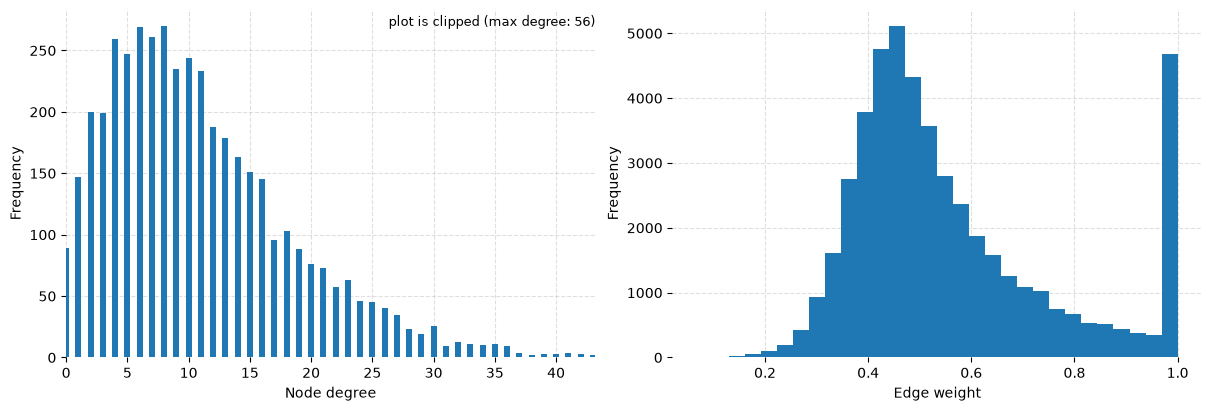

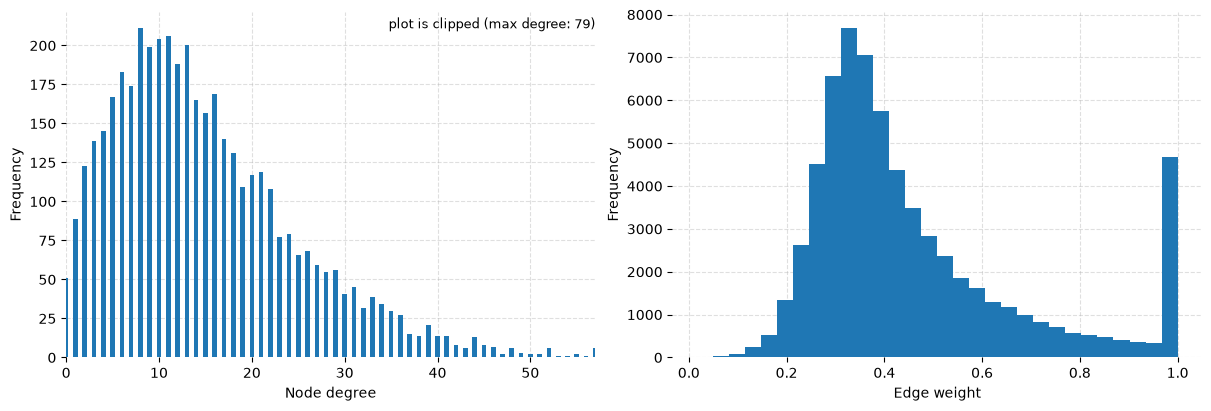

In [4]:
import scarf.plotting as splt

matrix_k11 = ds.load_graph(graph_loc=ds.inspect_artifact(graph_k11).path)
matrix_k15 = ds.load_graph(graph_loc=ds.inspect_artifact(graph_k15).path)
print('edges (nnz):', {'k11': matrix_k11.nnz, 'k15': matrix_k15.nnz})
splt.graph_qc(matrix_k11)
splt.graph_qc(matrix_k15)

In [5]:
pca_dims20 = ds.run_pca(normalized, dims=20, update_state=False)
ann_dims20 = ds.build_ann_index(pca_dims20, update_state=False)
neighbors_dims20 = ds.query_neighbors(ann_dims20, k=11, update_state=False)
graph_dims20 = ds.build_connectivity_map(neighbors_dims20, update_state=False)

print('PCA recomputed:', pca_dims20 != pca)
print('ANN index recomputed:', ann_dims20 != ann)
print('neighbors recomputed:', neighbors_dims20 != neighbors_k11)
print('graph recomputed:', graph_dims20 != graph_k11)
print('normalization reused:', ds.run_normalization(feat_key='hvgs', update_state=False) == normalized)

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

PCA recomputed: True
ANN index recomputed: True
neighbors recomputed: True
graph recomputed: True
normalization reused: True


In [6]:
forced = ds.run_normalization(
    feat_key='hvgs',
    update_state=False,
    invalidate_cache=True,
)
status = ds.inspect_artifact(forced)
baseline = ds.inspect_artifact(normalized)
baseline_inputs = baseline.inputs or {}
forced_inputs = status.inputs or {}

print('new artifact:', forced != normalized)
print('complete:', status.complete)
print('operation:', status.operation)
print('path:', status.path)
print('baseline path:', baseline.path)
print('same parameters:', status.parameters == baseline.parameters)
print('same input roles:', set(baseline_inputs) == set(forced_inputs))
print('same inputs:', forced_inputs == baseline_inputs)
for name in sorted(set(baseline_inputs) | set(forced_inputs)):
    left = baseline_inputs.get(name)
    right = forced_inputs.get(name)
    if left == right:
        print(f'{name}: same')
        continue
    print(f'{name}: different artifact id')
    print('  baseline:', left)
    print('  forced:', right)

Writing data: 1 / 1 complete

new artifact: True
complete: True
operation: run_normalization
path: RNA/artifacts/normalized/db959a939198e2bc49efdace111433a233a44f8f2a26811388e0ba7f3b44c54f
baseline path: RNA/artifacts/normalized/f13daf0fa722a3b87c87cec835141f819f231537a9591429ab094c29bf634d3e
same parameters: True
same input roles: True
same inputs: False
cell_selection: different artifact id
  baseline: {'type': 'artifact', 'scope': 'datastore', 'kind': 'cell_selection', 'artifact_id': 'e4199ad61c350f7d60bb3fee4dfaa0d42d3b4e11b8adddb2f216693d11cbc680'}
  forced: {'type': 'artifact', 'scope': 'datastore', 'kind': 'cell_selection', 'artifact_id': 'e819039930a61050429771ea9fc6ca264ad12131c563ca77f64105a964f48c3e'}
feature_selection: different artifact id
  baseline: {'type': 'artifact', 'scope': 'assay', 'kind': 'feature_selection', 'artifact_id': '8d7b4cb2a4c9ebbe2327f53d3d6667ad7373cd7684cd446b96973edc56cd177d', 'assay': 'RNA'}
  forced: {'type': 'artifact', 'scope': 'assay', 'kind': 'feature_selection', 'artifact_

In [7]:
lineage = ds.lineage(
    {
        'k11 graph': graph_k11,
        'k15 graph': graph_k15,
        'dims20 graph': graph_dims20,
    }
)
lineage

```mermaid
flowchart LR
    artifact0["datastore / cell_selection | filter_cells | e4199ad61c35"]
    artifact1["RNA / feature_selection | mark_hvgs | 8d7b4cb2a4c9"]
    artifact2["RNA / normalized | run_normalization | f13daf0fa722"]
    artifact3["RNA / feature_scaling | calculate_feature_scaling | 24d774a93aa6"]
    artifact4["RNA / reduction | run_pca | a56715fa3fbc"]
    artifact5["RNA / ann_index | build_ann_index | 2aab5cd65234"]
    artifact6["RNA / neighbors | query_neighbors | 6f4d7f0638bc"]
    artifact7["RNA / connectivity_map | build_connectivity_map | e277ac789419 | outputs: dims20 graph"]
    artifact8["RNA / reduction | run_pca | afcc5d17918e"]
    artifact9["RNA / ann_index | build_ann_index | 78daeda6b347"]
    artifact10["RNA / neighbors | query_neighbors | 4ee4caa6ea53"]
    artifact11["RNA / connectivity_map | build_connectivity_map | 5531fa7a890b | outputs: k11 graph"]
    artifact12["RNA / neighbors | query_neighbors | ca5561083221"]
    artifact13["RNA / connectivity_map | build_connectivity_map | 59f5005d0f53 | outputs: k15 graph"]
    artifact0 -->|"cell_selection"| artifact1
    artifact8 -->|"coordinates"| artifact10
    artifact9 -->|"ann_index"| artifact10
    artifact10 -->|"neighbors"| artifact11
    artifact8 -->|"coordinates"| artifact12
    artifact9 -->|"ann_index"| artifact12
    artifact12 -->|"neighbors"| artifact13
    artifact0 -->|"cell_selection"| artifact2
    artifact1 -->|"feature_selection"| artifact2
    artifact2 -->|"normalized"| artifact3
    artifact0 -->|"pca_cell_selection"| artifact4
    artifact2 -->|"normalized"| artifact4
    artifact3 -->|"feature_scaling"| artifact4
    artifact4 -->|"coordinates"| artifact5
    artifact4 -->|"coordinates"| artifact6
    artifact5 -->|"ann_index"| artifact6
    artifact6 -->|"neighbors"| artifact7
    artifact0 -->|"pca_cell_selection"| artifact8
    artifact2 -->|"normalized"| artifact8
    artifact3 -->|"feature_scaling"| artifact8
    artifact8 -->|"coordinates"| artifact9
```

### Artifact details

#### datastore / cell_selection / e4199ad61c35
- Status: `complete`
- Path: `artifacts/cell_selection/e4199ad61c350f7d60bb3fee4dfaa0d42d3b4e11b8adddb2f216693d11cbc680`
- Operation: `filter_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; highs=[15000,4000]; keep_bounds=false; lows=[1000,500]; reset_previous=true`
- Execution options: `source_column="I"`
- Other inputs: `metadata_fingerprints={"RNA_nCounts":"a8a7520000e32d28bcf97a8977290bcc7185570098e1fe95739c74687b435843","RNA_nFeatures":"a3df08addee7271194b0ebdfac85ad92ec93f3801031e65316776453eb...; ordered_row_ids_fingerprint="f5f05615ffc8833f75752b75152ccd728702f42950f81e9c28402880a4dd2ae5"; values_fingerprint="c56cd97011e0ca999890ff144c9e3b8c10121cd0ee887e0f69f9abd4512e68f2"`

#### RNA / feature_selection / 8d7b4cb2a4c9
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/8d7b4cb2a4c9ebbe2327f53d3d6667ad7373cd7684cd446b96973edc56cd177d`
- Operation: `mark_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; keep_bounds=false; lowess_frac=0.1; max_cells=4340; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; top_n=500`
- Execution options: `source_column="I__hvgs"`
- Other inputs: `ordered_row_ids_fingerprint="4548c9820ab9ed0afbc48cbb6503bdcdc725b57c65dbfe3c4da8bb480b7fc4b1"; values_fingerprint="50de7eea561b6ca70d4ec9bcdf40bdf2f5db47d6b81cf5be7b0c470958af44ff"`

#### RNA / normalized / f13daf0fa722
- Status: `complete`
- Path: `RNA/artifacts/normalized/f13daf0fa722a3b87c87cec835141f819f231537a9591429ab094c29bf634d3e`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"scarf.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `cell_key="I"; feat_key="hvgs"; from_assay="RNA"; invalidate_cache=false; update_state=false`

#### RNA / feature_scaling / 24d774a93aa6
- Status: `complete`
- Path: `RNA/artifacts/feature_scaling/24d774a93aa6f69ca396c61e2b48624ec6b883c234df3e0d8240d4f62ac4b97d`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"`

#### RNA / reduction / a56715fa3fbc
- Status: `complete`
- Path: `RNA/artifacts/reduction/a56715fa3fbca62783a81eedf6f496b2314033668e0d0d3f867c28fe0075e1af`
- Operation: `run_pca`
- Parameters: `dims=20; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 2aab5cd65234
- Status: `complete`
- Path: `RNA/artifacts/ann_index/2aab5cd65234ddcbec1d151a0194589fd36ff7a3b8abb4f532f2258f2da0f67c`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 6f4d7f0638bc
- Status: `complete`
- Path: `RNA/artifacts/neighbors/6f4d7f0638bc4e0797a6fd53fa86aebe13d02b3f0aa56d63e657739109d3cd03`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / e277ac789419
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/e277ac7894194a2c1119d9a5fc0f6a9f648399208f93f1f3a07e417ddc0a25a1`
- Operation: `build_connectivity_map`
- Outputs: `dims20 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / reduction / afcc5d17918e
- Status: `complete`
- Path: `RNA/artifacts/reduction/afcc5d17918ed1bdf9ebaef1b7a633373c57872c729d53c29bac7d574c9ff99c`
- Operation: `run_pca`
- Parameters: `dims=15; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 78daeda6b347
- Status: `complete`
- Path: `RNA/artifacts/ann_index/78daeda6b34749a934990a5f210bd1285115ea7259fef19f3c87e610f8cf8ec5`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 4ee4caa6ea53
- Status: `complete`
- Path: `RNA/artifacts/neighbors/4ee4caa6ea53d02e74e4ecbecc01c612f680eeb839fe8c3ec0e845e8095c64ca`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 5531fa7a890b
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/5531fa7a890b6cdaaa3c65f4cdea71b00c7c8ec1d5ea1738e34cfb2eb9abe414`
- Operation: `build_connectivity_map`
- Outputs: `k11 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / neighbors / ca5561083221
- Status: `complete`
- Path: `RNA/artifacts/neighbors/ca5561083221b2850ef1e89a1747b4e0635b7b5a0dd07cf9b71f4d6bcbcbb3c8`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=15`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 59f5005d0f53
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/59f5005d0f53d245d0a5ae7f592510de23c2b10a80671986c85a181802710543`
- Operation: `build_connectivity_map`
- Outputs: `k15 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

In [8]:
from IPython.display import Markdown

Markdown(lineage.to_markdown())

```mermaid
flowchart LR
    artifact0["datastore / cell_selection | filter_cells | e4199ad61c35"]
    artifact1["RNA / feature_selection | mark_hvgs | 8d7b4cb2a4c9"]
    artifact2["RNA / normalized | run_normalization | f13daf0fa722"]
    artifact3["RNA / feature_scaling | calculate_feature_scaling | 24d774a93aa6"]
    artifact4["RNA / reduction | run_pca | a56715fa3fbc"]
    artifact5["RNA / ann_index | build_ann_index | 2aab5cd65234"]
    artifact6["RNA / neighbors | query_neighbors | 6f4d7f0638bc"]
    artifact7["RNA / connectivity_map | build_connectivity_map | e277ac789419 | outputs: dims20 graph"]
    artifact8["RNA / reduction | run_pca | afcc5d17918e"]
    artifact9["RNA / ann_index | build_ann_index | 78daeda6b347"]
    artifact10["RNA / neighbors | query_neighbors | 4ee4caa6ea53"]
    artifact11["RNA / connectivity_map | build_connectivity_map | 5531fa7a890b | outputs: k11 graph"]
    artifact12["RNA / neighbors | query_neighbors | ca5561083221"]
    artifact13["RNA / connectivity_map | build_connectivity_map | 59f5005d0f53 | outputs: k15 graph"]
    artifact0 -->|"cell_selection"| artifact1
    artifact8 -->|"coordinates"| artifact10
    artifact9 -->|"ann_index"| artifact10
    artifact10 -->|"neighbors"| artifact11
    artifact8 -->|"coordinates"| artifact12
    artifact9 -->|"ann_index"| artifact12
    artifact12 -->|"neighbors"| artifact13
    artifact0 -->|"cell_selection"| artifact2
    artifact1 -->|"feature_selection"| artifact2
    artifact2 -->|"normalized"| artifact3
    artifact0 -->|"pca_cell_selection"| artifact4
    artifact2 -->|"normalized"| artifact4
    artifact3 -->|"feature_scaling"| artifact4
    artifact4 -->|"coordinates"| artifact5
    artifact4 -->|"coordinates"| artifact6
    artifact5 -->|"ann_index"| artifact6
    artifact6 -->|"neighbors"| artifact7
    artifact0 -->|"pca_cell_selection"| artifact8
    artifact2 -->|"normalized"| artifact8
    artifact3 -->|"feature_scaling"| artifact8
    artifact8 -->|"coordinates"| artifact9
```

### Artifact details

#### datastore / cell_selection / e4199ad61c35
- Status: `complete`
- Path: `artifacts/cell_selection/e4199ad61c350f7d60bb3fee4dfaa0d42d3b4e11b8adddb2f216693d11cbc680`
- Operation: `filter_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; highs=[15000,4000]; keep_bounds=false; lows=[1000,500]; reset_previous=true`
- Execution options: `source_column="I"`
- Other inputs: `metadata_fingerprints={"RNA_nCounts":"a8a7520000e32d28bcf97a8977290bcc7185570098e1fe95739c74687b435843","RNA_nFeatures":"a3df08addee7271194b0ebdfac85ad92ec93f3801031e65316776453eb...; ordered_row_ids_fingerprint="f5f05615ffc8833f75752b75152ccd728702f42950f81e9c28402880a4dd2ae5"; values_fingerprint="c56cd97011e0ca999890ff144c9e3b8c10121cd0ee887e0f69f9abd4512e68f2"`

#### RNA / feature_selection / 8d7b4cb2a4c9
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/8d7b4cb2a4c9ebbe2327f53d3d6667ad7373cd7684cd446b96973edc56cd177d`
- Operation: `mark_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; keep_bounds=false; lowess_frac=0.1; max_cells=4340; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; top_n=500`
- Execution options: `source_column="I__hvgs"`
- Other inputs: `ordered_row_ids_fingerprint="4548c9820ab9ed0afbc48cbb6503bdcdc725b57c65dbfe3c4da8bb480b7fc4b1"; values_fingerprint="50de7eea561b6ca70d4ec9bcdf40bdf2f5db47d6b81cf5be7b0c470958af44ff"`

#### RNA / normalized / f13daf0fa722
- Status: `complete`
- Path: `RNA/artifacts/normalized/f13daf0fa722a3b87c87cec835141f819f231537a9591429ab094c29bf634d3e`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"scarf.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `cell_key="I"; feat_key="hvgs"; from_assay="RNA"; invalidate_cache=false; update_state=false`

#### RNA / feature_scaling / 24d774a93aa6
- Status: `complete`
- Path: `RNA/artifacts/feature_scaling/24d774a93aa6f69ca396c61e2b48624ec6b883c234df3e0d8240d4f62ac4b97d`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"`

#### RNA / reduction / a56715fa3fbc
- Status: `complete`
- Path: `RNA/artifacts/reduction/a56715fa3fbca62783a81eedf6f496b2314033668e0d0d3f867c28fe0075e1af`
- Operation: `run_pca`
- Parameters: `dims=20; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 2aab5cd65234
- Status: `complete`
- Path: `RNA/artifacts/ann_index/2aab5cd65234ddcbec1d151a0194589fd36ff7a3b8abb4f532f2258f2da0f67c`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 6f4d7f0638bc
- Status: `complete`
- Path: `RNA/artifacts/neighbors/6f4d7f0638bc4e0797a6fd53fa86aebe13d02b3f0aa56d63e657739109d3cd03`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / e277ac789419
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/e277ac7894194a2c1119d9a5fc0f6a9f648399208f93f1f3a07e417ddc0a25a1`
- Operation: `build_connectivity_map`
- Outputs: `dims20 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / reduction / afcc5d17918e
- Status: `complete`
- Path: `RNA/artifacts/reduction/afcc5d17918ed1bdf9ebaef1b7a633373c57872c729d53c29bac7d574c9ff99c`
- Operation: `run_pca`
- Parameters: `dims=15; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 78daeda6b347
- Status: `complete`
- Path: `RNA/artifacts/ann_index/78daeda6b34749a934990a5f210bd1285115ea7259fef19f3c87e610f8cf8ec5`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 4ee4caa6ea53
- Status: `complete`
- Path: `RNA/artifacts/neighbors/4ee4caa6ea53d02e74e4ecbecc01c612f680eeb839fe8c3ec0e845e8095c64ca`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 5531fa7a890b
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/5531fa7a890b6cdaaa3c65f4cdea71b00c7c8ec1d5ea1738e34cfb2eb9abe414`
- Operation: `build_connectivity_map`
- Outputs: `k11 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / neighbors / ca5561083221
- Status: `complete`
- Path: `RNA/artifacts/neighbors/ca5561083221b2850ef1e89a1747b4e0635b7b5a0dd07cf9b71f4d6bcbcbb3c8`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=15`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 59f5005d0f53
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/59f5005d0f53d245d0a5ae7f592510de23c2b10a80671986c85a181802710543`
- Operation: `build_connectivity_map`
- Outputs: `k15 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`